
  PORTFOLIO RISK & RETURN ANALYSIS

yfinance not installed — generating synthetic data...
  1260 trading days | 5 assets

Expected Returns (annualised):
AAPL     37.86
MSFT     29.70
GOOGL    18.45
AMZN     -7.13
TSLA    -17.98 



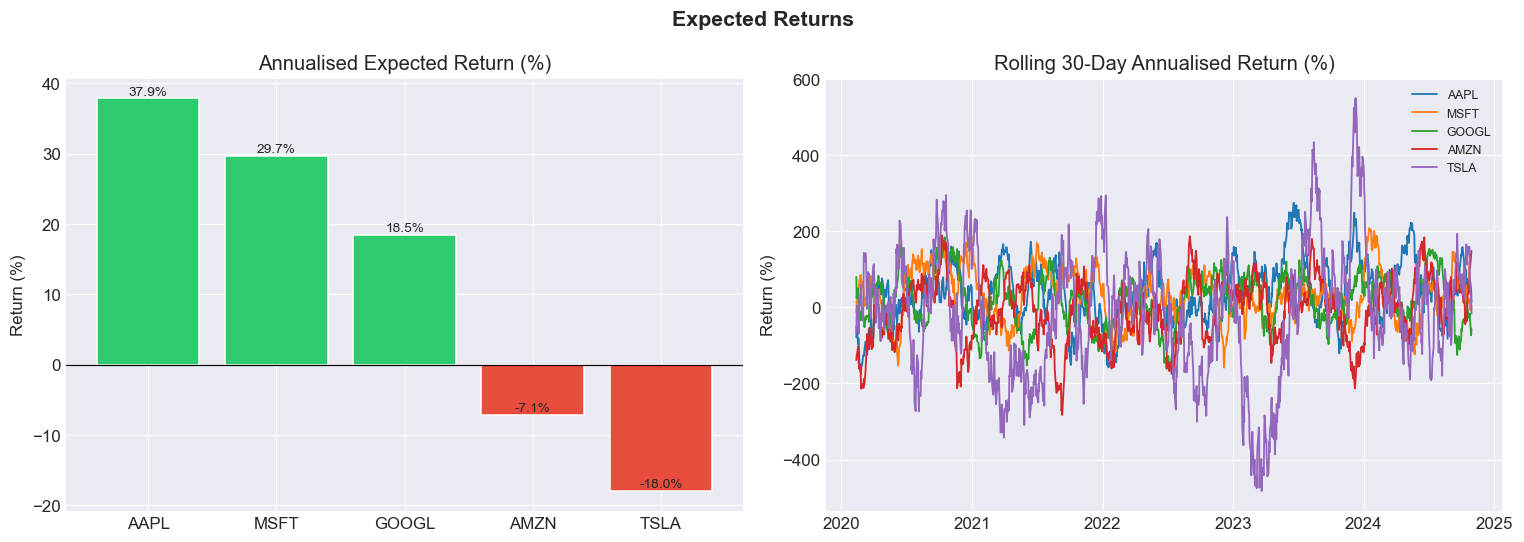

expected_returns.png saved



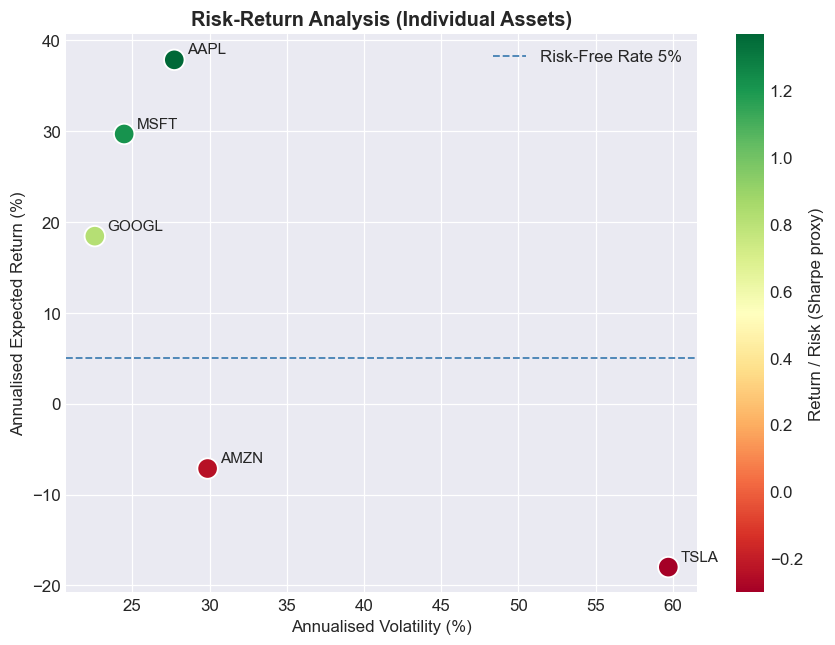

risk_return.png saved

Asset     Exp.Ret%  Volatility%   Sharpe
--------------------------------------------------
AAPL         37.86        27.71    1.186
MSFT         29.70        24.47    1.009
GOOGL        18.45        22.57    0.596
AMZN         -7.13        29.87   -0.406
TSLA        -17.98        59.70   -0.385
Risk-Free Rate (annualised): 5.0%



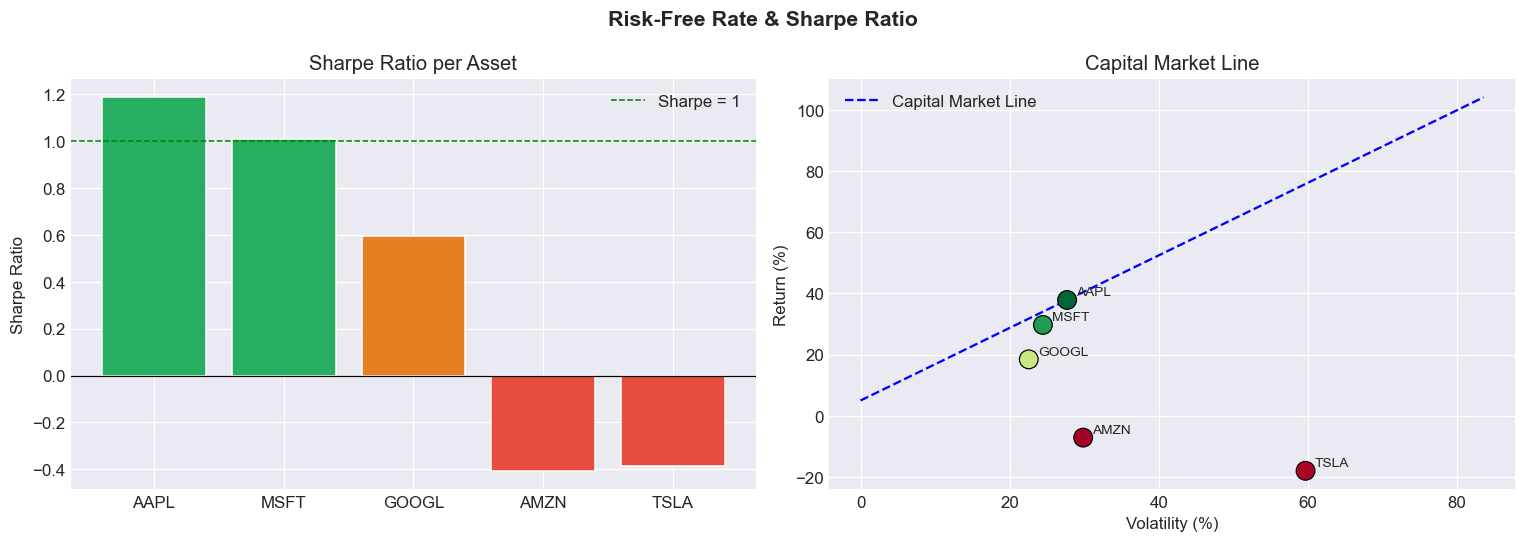

sharpe_cml.png saved

Running Monte-Carlo simulation...


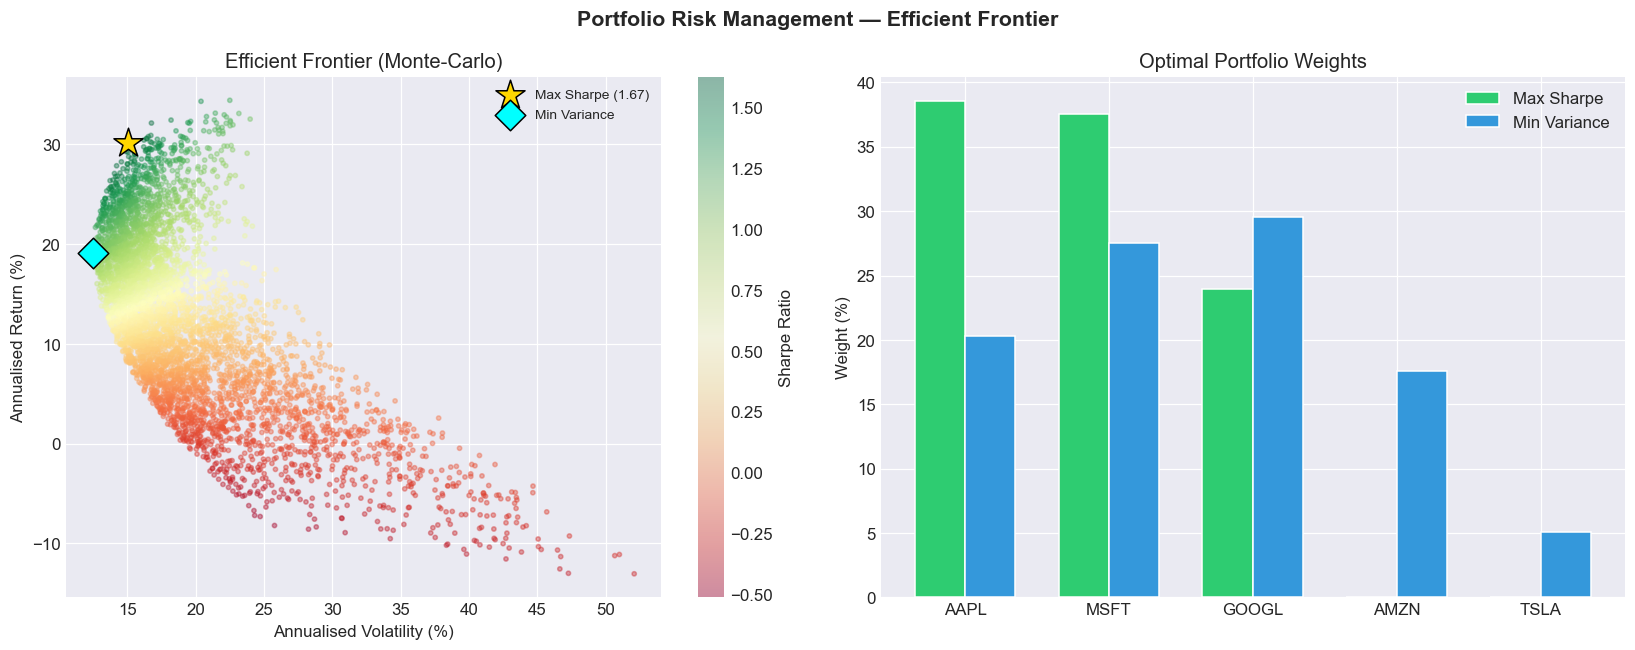

Optimal Portfolios:
  Max Sharpe   -> Return: 30.1%  Vol: 15.0%  Sharpe: 1.672
  Min Variance -> Return: 19.1%  Vol: 12.5%  Sharpe: 1.132
efficient_frontier.png saved



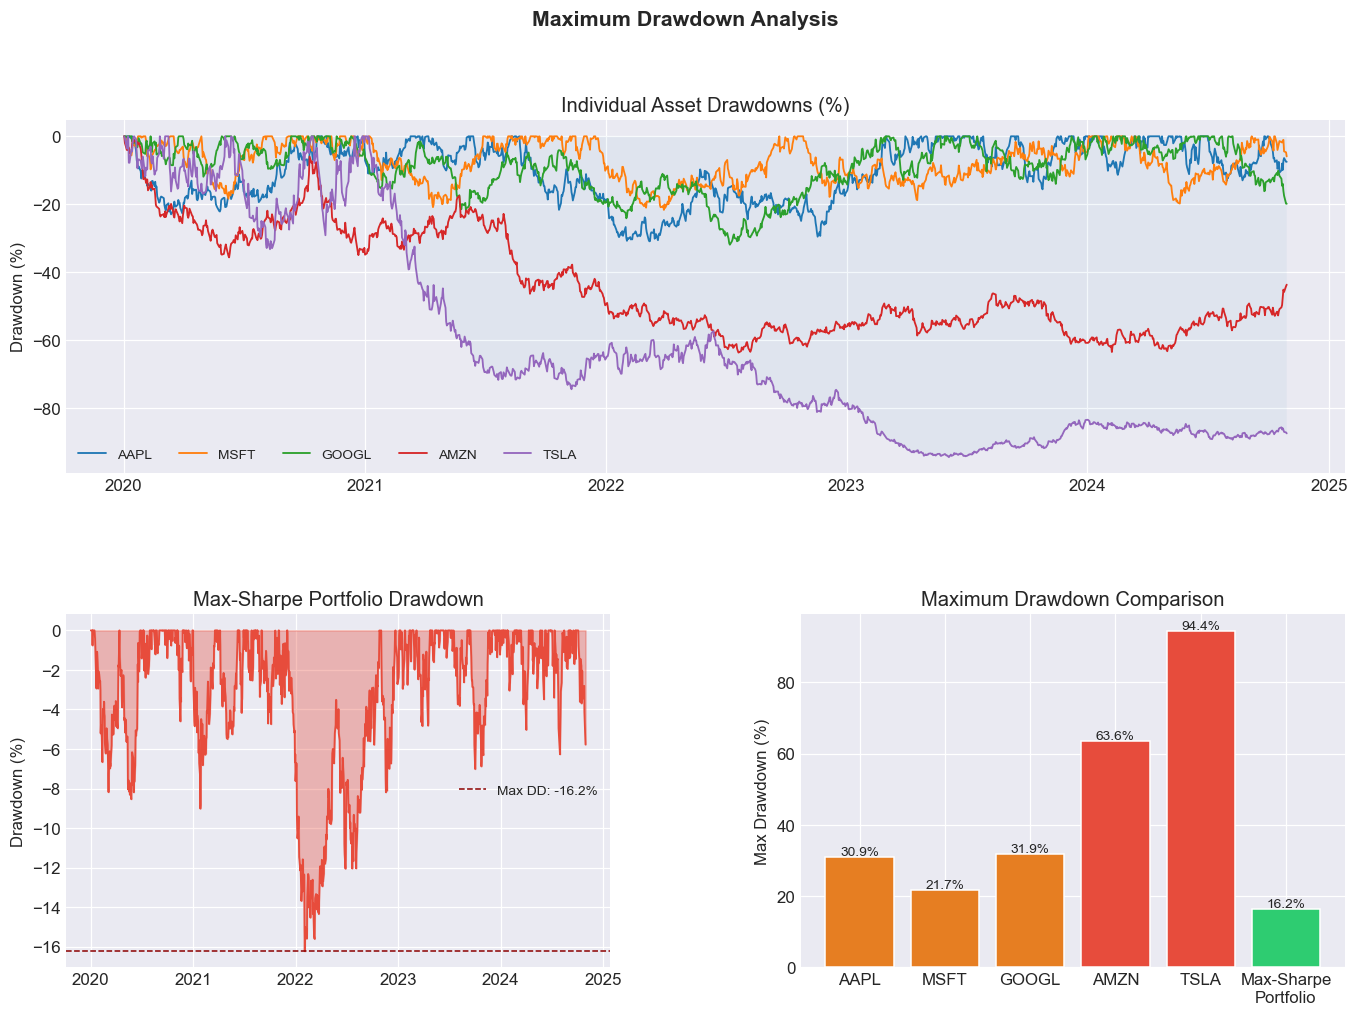


Maximum Drawdown Summary:
  AAPL                   30.91%
  MSFT                   21.66%
  GOOGL                  31.90%
  AMZN                   63.64%
  TSLA                   94.41%
  Max-Sharpe Portfolio   16.23%
maximum_drawdown.png saved

Portfolio VaR  (95%): -1.401% per day
Portfolio CVaR (95%): -1.821% per day


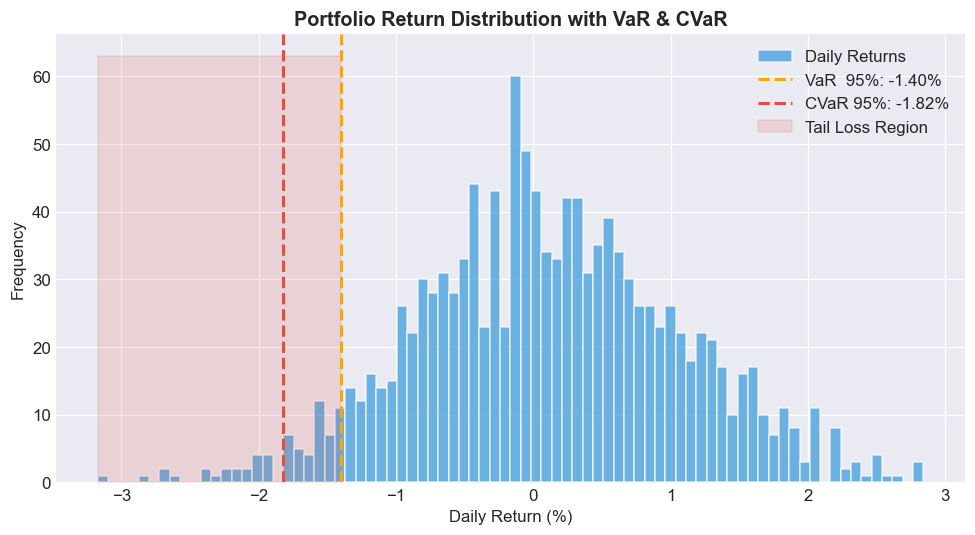

var_cvar.png saved


All analyses complete!
Saved: expected_returns.png | risk_return.png | sharpe_cml.png | efficient_frontier.png | maximum_drawdown.png | var_cvar.png


In [1]:
"""

  PORTFOLIO RISK & RETURN ANALYSIS
  Topics:
    1. Risk-Return Analysis
    2. Expected Returns
    3. Risk-Free Rate & Sharpe Ratio
    4. Portfolio Risk Management (Efficient Frontier)
    5. Maximum Drawdown

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

# ── Optional: real data via yfinance 
try:
    import yfinance as yf
    USE_REAL_DATA = True
except ImportError:
    USE_REAL_DATA = False

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})



#  CONFIG

TICKERS      = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
START        = "2020-01-01"
END          = "2024-12-31"
RF_ANNUAL    = 0.05
TRADING_DAYS = 252
N_PORTFOLIOS = 5_000



#  1. DATA LOADING

def load_data():
    if USE_REAL_DATA:
        print("Fetching real prices via yfinance...")
        raw    = yf.download(TICKERS, start=START, end=END, auto_adjust=True)["Close"]
        prices = raw.dropna()
    else:
        print("yfinance not installed — generating synthetic data...")
        np.random.seed(42)
        n      = 1_260
        dates  = pd.bdate_range(START, periods=n)
        mus    = [0.25, 0.22, 0.18, 0.20, 0.35]
        sigs   = [0.28, 0.25, 0.22, 0.30, 0.60]
        price0 = [150, 300, 140, 180, 250]
        data   = {}
        for i, t in enumerate(TICKERS):
            dt     = 1 / TRADING_DAYS
            drifts = (mus[i] - 0.5 * sigs[i]**2) * dt
            shocks = sigs[i] * np.sqrt(dt) * np.random.randn(n)
            log_r  = drifts + shocks
            data[t] = price0[i] * np.exp(np.cumsum(log_r))
        prices = pd.DataFrame(data, index=dates)

    print(f"  {len(prices)} trading days | {len(prices.columns)} assets\n")
    return prices



#  2. EXPECTED RETURNS

def compute_expected_returns(prices):
    """Daily log-returns -> annualised mean & covariance."""
    log_ret  = np.log(prices / prices.shift(1)).dropna()
    mean_ann = log_ret.mean() * TRADING_DAYS
    cov_ann  = log_ret.cov()  * TRADING_DAYS
    return log_ret, mean_ann, cov_ann


def plot_expected_returns(mean_ann, log_ret):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Expected Returns", fontsize=14, fontweight="bold")

    # Bar chart — annualised expected return
    colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in mean_ann]
    axes[0].bar(mean_ann.index, mean_ann.values * 100, color=colors, edgecolor="white")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Annualised Expected Return (%)")
    axes[0].set_ylabel("Return (%)")
    for i, v in enumerate(mean_ann):
        axes[0].text(i, v * 100 + 0.5, f"{v*100:.1f}%", ha="center", fontsize=9)

    # Rolling 30-day return
    roll = log_ret.rolling(30).mean() * TRADING_DAYS
    for col in roll.columns:
        axes[1].plot(roll.index, roll[col] * 100, label=col, linewidth=1.2)
    axes[1].set_title("Rolling 30-Day Annualised Return (%)")
    axes[1].set_ylabel("Return (%)")
    axes[1].legend(fontsize=8)
    axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.savefig("expected_returns.png")
    plt.show()
    print("expected_returns.png saved\n")



#  3. RISK-RETURN ANALYSIS (individual assets)

def plot_risk_return(mean_ann, cov_ann):
    vols = np.sqrt(np.diag(cov_ann.values))
    rets = mean_ann.values

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Risk-Return Analysis (Individual Assets)", fontsize=13, fontweight="bold")
    scatter = ax.scatter(vols * 100, rets * 100,
                         s=180, c=rets / vols,
                         cmap="RdYlGn", edgecolors="white", linewidths=1.2, zorder=3)
    plt.colorbar(scatter, ax=ax, label="Return / Risk (Sharpe proxy)")

    for i, t in enumerate(mean_ann.index):
        ax.annotate(t, (vols[i] * 100, rets[i] * 100),
                    textcoords="offset points", xytext=(8, 4), fontsize=10)

    ax.set_xlabel("Annualised Volatility (%)")
    ax.set_ylabel("Annualised Expected Return (%)")
    ax.axhline(RF_ANNUAL * 100, color="steelblue", linestyle="--",
               linewidth=1.2, label=f"Risk-Free Rate {RF_ANNUAL*100:.0f}%")
    ax.legend()
    plt.tight_layout()
    plt.savefig("risk_return.png")
    plt.show()
    print("risk_return.png saved\n")



#  4. RISK-FREE RATE & SHARPE RATIO

def compute_sharpe(mean_ann, cov_ann):
    vols   = np.sqrt(np.diag(cov_ann.values))
    sharpe = (mean_ann.values - RF_ANNUAL) / vols

    print("=" * 50)
    print(f"{'Asset':<8} {'Exp.Ret%':>9} {'Volatility%':>12} {'Sharpe':>8}")
    print("-" * 50)
    for t, r, v, s in zip(mean_ann.index, mean_ann.values, vols, sharpe):
        print(f"{t:<8} {r*100:>9.2f} {v*100:>12.2f} {s:>8.3f}")
    print("=" * 50)
    print(f"Risk-Free Rate (annualised): {RF_ANNUAL*100:.1f}%\n")
    return sharpe


def plot_sharpe(mean_ann, cov_ann, sharpe):
    vols = np.sqrt(np.diag(cov_ann.values))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Risk-Free Rate & Sharpe Ratio", fontsize=14, fontweight="bold")

    # Sharpe bars
    colors = ["#27ae60" if s > 1 else "#e67e22" if s > 0 else "#e74c3c" for s in sharpe]
    axes[0].bar(mean_ann.index, sharpe, color=colors, edgecolor="white")
    axes[0].axhline(1, color="green", linestyle="--", linewidth=1, label="Sharpe = 1")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Sharpe Ratio per Asset")
    axes[0].set_ylabel("Sharpe Ratio")
    axes[0].legend()

    # Capital Market Line
    x_range   = np.linspace(0, max(vols) * 1.4, 300)
    best_idx  = np.argmax(sharpe)
    cml_slope = sharpe[best_idx]
    axes[1].plot(x_range * 100, (RF_ANNUAL + cml_slope * x_range) * 100,
                 "b--", linewidth=1.5, label="Capital Market Line")
    axes[1].scatter(vols * 100, mean_ann.values * 100,
                    s=150, c=sharpe, cmap="RdYlGn", edgecolors="k",
                    linewidths=0.8, zorder=3)
    for i, t in enumerate(mean_ann.index):
        axes[1].annotate(t, (vols[i] * 100, mean_ann.values[i] * 100),
                         textcoords="offset points", xytext=(6, 3), fontsize=9)
    axes[1].set_title("Capital Market Line")
    axes[1].set_xlabel("Volatility (%)")
    axes[1].set_ylabel("Return (%)")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig("sharpe_cml.png")
    plt.show()
    print("sharpe_cml.png saved\n")



#  5. PORTFOLIO RISK MANAGEMENT — Efficient Frontier

def portfolio_stats(weights, mean_ann, cov_ann):
    ret    = np.dot(weights, mean_ann.values)
    vol    = np.sqrt(weights @ cov_ann.values @ weights)
    sharpe = (ret - RF_ANNUAL) / vol
    return ret, vol, sharpe


def simulate_portfolios(mean_ann, cov_ann):
    n            = len(mean_ann)
    results      = np.zeros((N_PORTFOLIOS, 3))
    weight_store = np.zeros((N_PORTFOLIOS, n))

    for i in range(N_PORTFOLIOS):
        w               = np.random.dirichlet(np.ones(n))
        r, v, s         = portfolio_stats(w, mean_ann, cov_ann)
        results[i]      = [r, v, s]
        weight_store[i] = w

    return results, weight_store


def find_optimal_portfolios(mean_ann, cov_ann):
    n      = len(mean_ann)
    bounds = [(0, 1)] * n
    cons   = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

    # Maximum Sharpe
    def neg_sharpe(w):
        return -portfolio_stats(w, mean_ann, cov_ann)[2]

    res_sharpe = minimize(neg_sharpe, x0=np.ones(n)/n, bounds=bounds, constraints=cons)
    w_sharpe   = res_sharpe.x

    # Minimum Variance
    def port_vol(w):
        return portfolio_stats(w, mean_ann, cov_ann)[1]

    res_minvol = minimize(port_vol, x0=np.ones(n)/n, bounds=bounds, constraints=cons)
    w_minvol   = res_minvol.x

    return w_sharpe, w_minvol


def plot_efficient_frontier(mean_ann, cov_ann, results, weight_store):
    w_sharpe, w_minvol  = find_optimal_portfolios(mean_ann, cov_ann)
    r_s, v_s, sh_s      = portfolio_stats(w_sharpe, mean_ann, cov_ann)
    r_m, v_m, sh_m      = portfolio_stats(w_minvol, mean_ann, cov_ann)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("Portfolio Risk Management — Efficient Frontier", fontsize=14, fontweight="bold")

    # Scatter of simulated portfolios
    sc = axes[0].scatter(results[:, 1] * 100, results[:, 0] * 100,
                         c=results[:, 2], cmap="RdYlGn", alpha=0.4, s=8)
    plt.colorbar(sc, ax=axes[0], label="Sharpe Ratio")
    axes[0].scatter(v_s * 100, r_s * 100, marker="*", s=400, color="gold",
                    edgecolors="k", zorder=5, label=f"Max Sharpe ({sh_s:.2f})")
    axes[0].scatter(v_m * 100, r_m * 100, marker="D", s=200, color="cyan",
                    edgecolors="k", zorder=5, label="Min Variance")
    axes[0].set_xlabel("Annualised Volatility (%)")
    axes[0].set_ylabel("Annualised Return (%)")
    axes[0].set_title("Efficient Frontier (Monte-Carlo)")
    axes[0].legend(fontsize=9)

    # Optimal weights comparison
    x = np.arange(len(mean_ann))
    w = 0.35
    axes[1].bar(x - w/2, w_sharpe * 100, width=w, label="Max Sharpe",   color="#2ecc71", edgecolor="white")
    axes[1].bar(x + w/2, w_minvol * 100, width=w, label="Min Variance", color="#3498db", edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(mean_ann.index)
    axes[1].set_ylabel("Weight (%)")
    axes[1].set_title("Optimal Portfolio Weights")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("efficient_frontier.png")
    plt.show()

    print("Optimal Portfolios:")
    print(f"  Max Sharpe   -> Return: {r_s*100:.1f}%  Vol: {v_s*100:.1f}%  Sharpe: {sh_s:.3f}")
    print(f"  Min Variance -> Return: {r_m*100:.1f}%  Vol: {v_m*100:.1f}%  Sharpe: {sh_m:.3f}")
    print("efficient_frontier.png saved\n")
    return w_sharpe, w_minvol



#  6. MAXIMUM DRAWDOWN

def maximum_drawdown(cum_returns):
    """Returns drawdown series and scalar max-drawdown value."""
    rolling_max = cum_returns.cummax()
    drawdown    = (cum_returns - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    return drawdown, max_dd


def build_portfolio_value(prices, weights):
    log_ret  = np.log(prices / prices.shift(1)).dropna()
    port_ret = log_ret @ weights
    cum_val  = (1 + port_ret).cumprod()
    return cum_val


def plot_drawdown(prices, w_sharpe, w_minvol, mean_ann):
    log_ret = np.log(prices / prices.shift(1)).dropna()
    fig     = plt.figure(figsize=(15, 10))
    gs      = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    fig.suptitle("Maximum Drawdown Analysis", fontsize=14, fontweight="bold")

    # Individual asset drawdowns
    ax1 = fig.add_subplot(gs[0, :])
    last_dd = None
    for col in log_ret.columns:
        cum       = (1 + log_ret[col]).cumprod()
        dd, _     = maximum_drawdown(cum)
        last_dd   = dd
        ax1.plot(dd.index, dd * 100, label=col, linewidth=1.2)
    if last_dd is not None:
        ax1.fill_between(last_dd.index, last_dd * 100, 0, alpha=0.05)
    ax1.set_title("Individual Asset Drawdowns (%)")
    ax1.set_ylabel("Drawdown (%)")
    ax1.legend(fontsize=9, ncol=len(log_ret.columns))
    ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))

    # Max-Sharpe portfolio drawdown
    ax2        = fig.add_subplot(gs[1, 0])
    cum_s      = build_portfolio_value(prices, w_sharpe)
    dd_s, mdd_s = maximum_drawdown(cum_s)
    ax2.fill_between(dd_s.index, dd_s * 100, 0, color="#e74c3c", alpha=0.35)
    ax2.plot(dd_s.index, dd_s * 100, color="#e74c3c", linewidth=1.2)
    ax2.axhline(mdd_s * 100, linestyle="--", color="darkred",
                linewidth=1, label=f"Max DD: {mdd_s*100:.1f}%")
    ax2.set_title("Max-Sharpe Portfolio Drawdown")
    ax2.set_ylabel("Drawdown (%)")
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))

    # Max-drawdown summary bar
    ax3         = fig.add_subplot(gs[1, 1])
    labels, mdds = [], []
    for col in log_ret.columns:
        cum      = (1 + log_ret[col]).cumprod()
        _, mdd   = maximum_drawdown(cum)
        labels.append(col)
        mdds.append(abs(mdd) * 100)

    # Add portfolio
    _, mdd_port = maximum_drawdown(cum_s)
    labels.append("Max-Sharpe\nPortfolio")
    mdds.append(abs(mdd_port) * 100)

    colors = ["#e74c3c" if v > 40 else "#e67e22" if v > 20 else "#2ecc71" for v in mdds]
    bars   = ax3.bar(labels, mdds, color=colors, edgecolor="white")
    ax3.set_title("Maximum Drawdown Comparison")
    ax3.set_ylabel("Max Drawdown (%)")
    for bar, val in zip(bars, mdds):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=9)

    plt.savefig("maximum_drawdown.png")
    plt.show()

    print("\nMaximum Drawdown Summary:")
    print("=" * 35)
    for lbl, val in zip(labels, mdds):
        print(f"  {lbl.replace(chr(10), ' '):<22} {val:.2f}%")
    print("maximum_drawdown.png saved\n")



#  7. VaR & CVaR (bonus risk metrics)

def compute_var_cvar(log_ret, weights, confidence=0.95):
    port_ret = log_ret @ weights
    var      = np.percentile(port_ret, (1 - confidence) * 100)
    cvar     = port_ret[port_ret <= var].mean()
    print(f"Portfolio VaR  ({confidence*100:.0f}%): {var*100:.3f}% per day")
    print(f"Portfolio CVaR ({confidence*100:.0f}%): {cvar*100:.3f}% per day")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(port_ret * 100, bins=80, color="#3498db", edgecolor="white",
            alpha=0.7, label="Daily Returns")
    ax.axvline(var  * 100, color="orange",  linewidth=2, linestyle="--",
               label=f"VaR  {confidence*100:.0f}%: {var*100:.2f}%")
    ax.axvline(cvar * 100, color="#e74c3c", linewidth=2, linestyle="--",
               label=f"CVaR {confidence*100:.0f}%: {cvar*100:.2f}%")

    # FIX: draw the plot first so get_ylim() returns real values
    fig.canvas.draw()
    ymax = ax.get_ylim()[1]
    ax.fill_betweenx([0, ymax], port_ret.min() * 100, var * 100,
                     color="#e74c3c", alpha=0.15, label="Tail Loss Region")

    ax.set_title("Portfolio Return Distribution with VaR & CVaR", fontsize=13, fontweight="bold")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.savefig("var_cvar.png")
    plt.show()
    print("var_cvar.png saved\n")



#  MAIN

def main():
    print("\n" + "=" * 55)
    print("  PORTFOLIO RISK & RETURN ANALYSIS")
    print("=" * 55 + "\n")

    # 1. Data
    prices = load_data()

    # 2. Expected Returns
    log_ret, mean_ann, cov_ann = compute_expected_returns(prices)
    print("Expected Returns (annualised):")
    print((mean_ann * 100).round(2).to_string(), "\n")
    plot_expected_returns(mean_ann, log_ret)

    # 3. Risk-Return
    plot_risk_return(mean_ann, cov_ann)

    # 4. Risk-Free Rate & Sharpe
    sharpe = compute_sharpe(mean_ann, cov_ann)
    plot_sharpe(mean_ann, cov_ann, sharpe)

    # 5. Efficient Frontier
    print("Running Monte-Carlo simulation...")
    results, weight_store = simulate_portfolios(mean_ann, cov_ann)
    w_sharpe, w_minvol    = plot_efficient_frontier(mean_ann, cov_ann, results, weight_store)

    # 6. Maximum Drawdown
    plot_drawdown(prices, w_sharpe, w_minvol, mean_ann)

    # 7. VaR & CVaR
    compute_var_cvar(log_ret, w_sharpe, confidence=0.95)

    print("\nAll analyses complete!")
    print("Saved: expected_returns.png | risk_return.png | sharpe_cml.png |"
          " efficient_frontier.png | maximum_drawdown.png | var_cvar.png")


if __name__ == "__main__":
    main()